<a href="https://colab.research.google.com/github/Hanmikoo/newurban-journey/blob/main/%EC%A4%91%EA%B0%84%EA%B3%BC%EC%A0%9C%EC%A0%9C%EC%B6%9C%ED%95%9C%EA%B1%B00404.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

컴퓨터 시각화 중간과제 - 202357-100034 구한미

In [ ]:
!pip install tensorflow matplotlib numpy pillow

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,603 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
!rm -rf ~/.cache/matplotlib

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔 폰트 경로 설정 (코랩 기본 경로)
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

# matplotlib에 폰트 적용
plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"✅ 설정된 폰트: {font_name}")

✅ 설정된 폰트: NanumBarunGothic


In [ ]:
# 기본 라이브러리
import numpy as np
import matplotlib.pyplot as plt
import os

# TensorFlow/Keras 라이브러리
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import rc

# 기본 글꼴을 NanumGothic으로 변경
rc('font', family='NanumGothic')

# 버전 확인
print(f"TensorFlow 버전: {tf.__version__}")
print(f"Keras 버전: {keras.__version__}")
print(f"NumPy 버전: {np.__version__}")

# GPU 사용 가능 여부 확인: GPU 사용량 제한으로 연결 못하고 CPU환경에서 사용함
print(f"\nGPU 사용 가능: {len(tf.config.list_physical_devices('GPU')) > 0}")
if tf.config.list_physical_devices('GPU'):
    print(f"감지된 GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow 버전: 2.19.0
Keras 버전: 3.13.2
NumPy 버전: 2.0.2

GPU 사용 가능: False


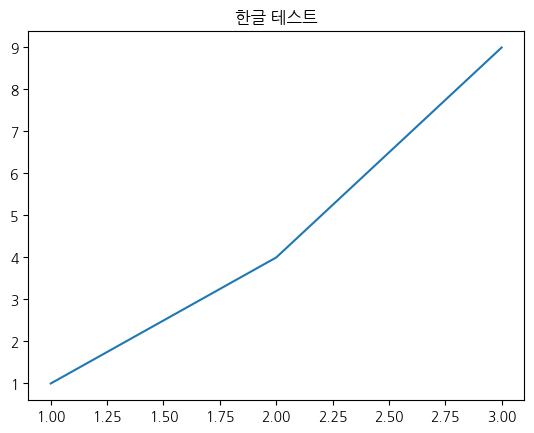

In [ ]:
plt.title("한글 테스트")
plt.plot([1,2,3],[1,4,9])
plt.show()

1.첫번째 실험 - 기본 CNN 모델 구축

In [ ]:
# 구글 드라이브와 코랩 연결
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. 경로를 'MyDrive'로 수정하고 따옴표로 감싸서 실행합니다.
!unzip -q "/content/drive/MyDrive/컴퓨터비전_중간과제.zip" -d "/content/dataset"


# 2. 불필요한 이중 zip 파일 삭제 (용량 확보 및 헷갈림 방지)
!rm -f /content/dataset/train.zip
!rm -f /content/dataset/test.zip

# 3. '10-2' 폴더 강제 삭제 (train, test 폴더 모두 적용)
!rm -rf /content/dataset/train/10-2
!rm -rf /content/dataset/test/10-2

print("✅ 압축 해제 및 10-2 폴더 삭제 완료!")

# 4. 결과 확인 (10-2 폴더가 잘 지워졌는지 확인합니다)
print("\n--- train 폴더 목록 ---")
!ls -F /content/dataset/train/

print("\n--- test 폴더 목록 ---")
!ls -F /content/dataset/test/


mapname:  conversion of  failed
replace /content/dataset/Untitled.ipynb? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ 압축 해제 및 10-2 폴더 삭제 완료!

--- train 폴더 목록 ---
1/  10/  10-1/	2/  3/	4/  5/	6/  7/	8/  9/

--- test 폴더 목록 ---
1/  10/  10-1/	2/  3/	4/  5/	6/  7/	8/  9/


In [ ]:
# 1. 10 폴더를 확실하게 생성
!mkdir -p /content/dataset/train/10
!mkdir -p /content/dataset/test/10

# 2. 10-1 폴더 안의 모든 이미지를 10 폴더로 복사
!cp -r /content/dataset/train/10-1/* /content/dataset/train/10/ 2>/dev/null
!cp -r /content/dataset/test/10-1/* /content/dataset/test/10/ 2>/dev/null

# 3. 필요 없어진 10-1 폴더 강제 삭제
!rm -rf /content/dataset/train/10-1
!rm -rf /content/dataset/test/10-1

print("✅ 10-1 데이터를 10 폴더로 병합 및 정리 완료!\n")

# 4. 결과 확인
print("--- 최종 train 폴더 목록 ---")
!ls -F /content/dataset/train/

print("\n--- 최종 test 폴더 목록 ---")
!ls -F /content/dataset/test/

✅ 10-1 데이터를 10 폴더로 병합 및 정리 완료!

--- 최종 train 폴더 목록 ---
1/  10/  2/  3/  4/  5/  6/  7/  8/  9/

--- 최종 test 폴더 목록 ---
1/  10/  2/  3/  4/  5/  6/  7/  8/  9/


참조 사이트(아이폰 등 최신기기 이미지를 처리하기 위해 'pillow-heif'라이브러리 사용

[pillow-heif 공식 문서](https://pillow-heif.readthedocs.io/en/stable/)

[Keras CNN 공식 튜토리얼](https://www.tensorflow.org/tutorials/images/cnn)

In [ ]:
# 1. 필수 라이브러리 설치 및 임포트
!pip install pillow-heif

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pillow_heif import register_heif_opener
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# HEIC 파일 인식을 위한 설정
register_heif_opener()

# --- 설정값 ---
base_path = '/content/dataset'
img_size = 64 # CPU 환경 고려

# 2. 데이터 로드 및 전처리 함수 (수정됨)
def load_and_preprocess_data(folder_name):
    images = []
    labels = []

    # train 또는 test 폴더 경로 설정
    target_path = os.path.join(base_path, folder_name)

    # 폴더 이름을 숫자로 변환하여 정렬 (1, 2, ... 10)
    class_names = sorted(
        [d for d in os.listdir(target_path) if os.path.isdir(os.path.join(target_path, d))],
        key=lambda x: int(x)
    )

    print(f"📁 {folder_name}에서 발견된 클래스: {class_names}")

    for i, class_name in enumerate(class_names):
        class_path = os.path.join(target_path, class_name)
        file_list = os.listdir(class_path)
        print(f"'{class_name}' 클래스 처리 중... ({len(file_list)}개 파일)")

        for img_name in file_list:
            img_path = os.path.join(class_path, img_name)
            try:
                # PIL로 열기
                img = Image.open(img_path).convert('RGB')
                # 리사이즈
                img = img.resize((img_size, img_size), Image.Resampling.LANCZOS)

                images.append(np.array(img))
                # i는 0부터 9까지의 숫자가 됩니다. (라벨링)
                labels.append(i)

            except Exception as e:
                continue

    return np.array(images), np.array(labels), class_names

# 3. 데이터 로드 실행
print("--- [1] Train 데이터 불러오기 ---")
X_train_raw, y_train_raw, classes = load_and_preprocess_data('train')

print("\n--- [2] Test 데이터 불러오기 ---")
X_test_raw, y_test_raw, _ = load_and_preprocess_data('test')

# 4. 정규화 (Normalization)
X_train_scaled = X_train_raw.astype('float32') / 255.0
X_test_scaled = X_test_raw.astype('float32') / 255.0

num_classes = len(classes) # 10개

# 5. 원-핫 인코딩 (One-Hot Encoding)
y_train_encoded = to_categorical(y_train_raw, num_classes)
y_test_encoded = to_categorical(y_test_raw, num_classes)

# 6. Train 데이터를 다시 Train(80%) : Val(20%)로 분할
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled, y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

# 최종 데이터 shape 확인
print("\n--- 데이터 준비 완료 ---")
print(f"1. 학습 데이터 (Train) : {X_train.shape}")
print(f"2. 검증 데이터 (Val)   : {X_val.shape}")
print(f"3. 테스트 데이터 (Test) : {X_test_scaled.shape}")

# 7. CNN 모델 구축 [CPU 최적화]
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # 과적합 방지
    layers.Dense(num_classes, activation='softmax') # 출력 노드 10개
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 35.5 MB/s eta 0:00:00
--- [1] Train 데이터 불러오기 ---
📁 train에서 발견된 클래스: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
'1' 클래스 처리 중... (70개 파일)
'2' 클래스 처리 중... (70개 파일)
'3' 클래스 처리 중... (76개 파일)
'4' 클래스 처리 중... (70개 파일)
'5' 클래스 처리 중... (74개 파일)
'6' 클래스 처리 중... (70개 파일)
'7' 클래스 처리 중... (70개 파일)
'8' 클래스 처리 중... (70개 파일)
'9' 클래스 처리 중... (70개 파일)
'10' 클래스 처리 중... (64개 파일)

--- [2] Test 데이터 불러오기 ---
📁 test에서 발견된 클래스: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
'1' 클래스 처리 중... (30개 파일)
'2' 클래스 처리 중... (30개 파일)
'3' 클래스 처리 중... (24개 파일)
'4' 클래스 처리 중... (30개 파일)
'5' 클래스 처리 중... (30개 파일)
'6' 클래스 처리 중... (30개 파일)
'7' 클래스 처리 중... (30개 파일)
'8' 클래스 처리 중... (30개 파일)
'9' 클래스 처리 중... (30개 파일)
'10' 클래스 처리 중... (36개 파일)

--- 데이터 준비 완료 ---
1. 학습 데이터 (Train) : (563, 64, 64, 3)
2. 검증 데이터 (Val)   : (141, 64, 64, 3)
3. 테스트 데이터 (Test) : (300, 64, 64, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

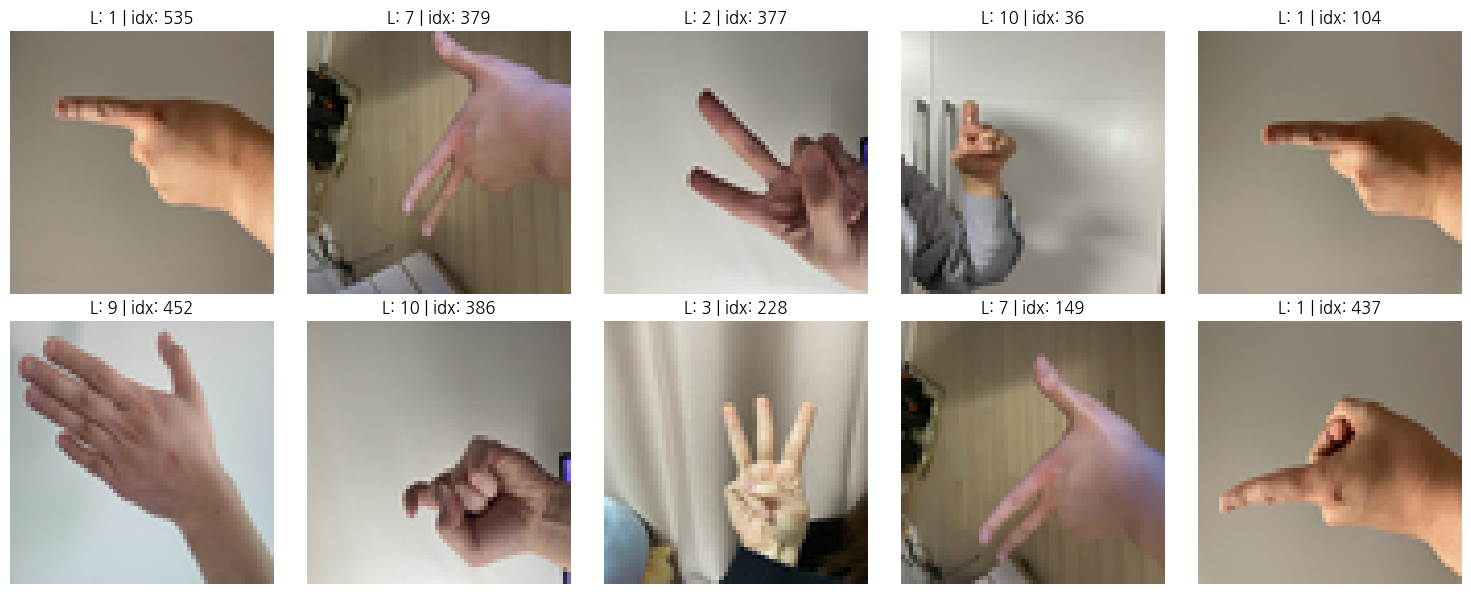

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 10개의 무작위 인덱스 생성
num_samples = 10
indices = np.random.randint(0, len(X_train), num_samples)

# 시각화 설정 (2행 5열)
plt.figure(figsize=(15, 6))

for i, index in enumerate(indices):
    plt.subplot(2, 5, i + 1)

    #  X_train_scaled 대신 최종 X_train 사용
    plt.imshow(X_train[index])

    # 현재 이미지의 라벨 정보 가져오기 (원-핫 인코딩 -> 정수형 라벨)
    current_label_idx = np.argmax(y_train[index])
    current_label_name = classes[current_label_idx]

    plt.title(f"L: {current_label_name} | idx: {index}")
    plt.axis('off') # 격자 숨기기

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks, optimizers

# --- 그래프를 그리는 함수 정의 ---
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # 1. Accuracy 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # 2. Loss 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# # 1. 하이퍼파라미터 설정
EPOCHS = 30
BATCH_SIZE = 16
opt = optimizers.Adam(learning_rate=0.0005)

# # 2. 모델 컴파일
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# # 3. 콜백 설정 (출력 최소화)
checkpoint = callbacks.ModelCheckpoint(
    'best_sign_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=0 #
)

print("▶ 모델 컴파일 및 콜백 설정 완료!")

# 4. 모델 학습 시작
print("▶ 학습을 시작합니다. (PDF 출력 최적화 모드) 🚀")

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, reduce_lr],
    verbose=0

)


▶ 모델 컴파일 및 콜백 설정 완료!
▶ 학습을 시작합니다. (PDF 출력 최적화 모드) 🚀



📊 최종 모델 성능 리포트
1. 학습 정확도 (Train Acc)   : 0.9556
2. 검증 정확도 (Val Acc)     : 0.6099
3. 테스트 정확도 (Test Acc)   : 0.2200 🚩 (최종 성적)
--------------------------------------------------
학습 손실 (Train Loss)       : 0.1953
검증 손실 (Val Loss)         : 1.2003
테스트 손실 (Test Loss)       : 3.7255


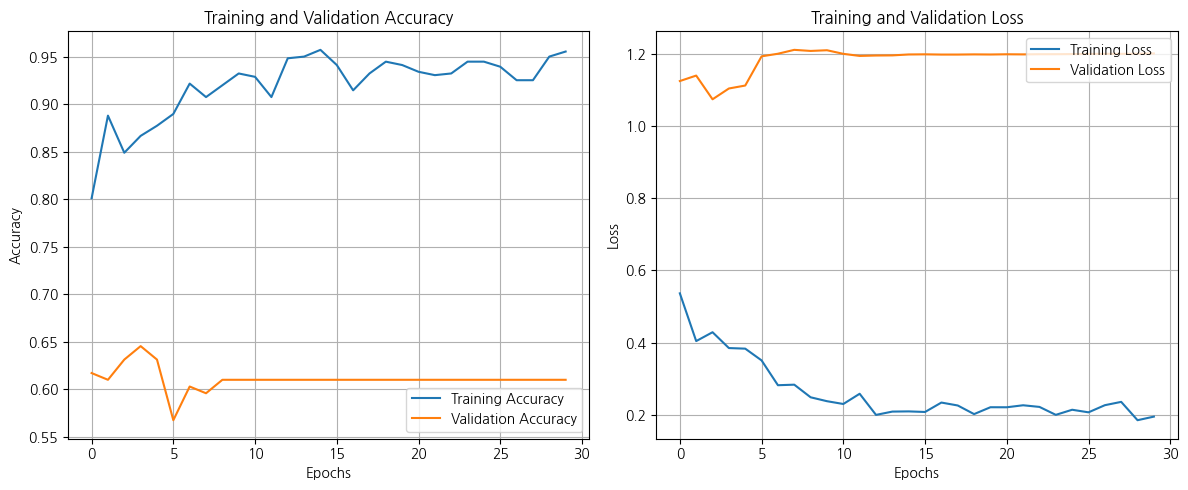

In [ ]:
# 1. 최적의 가중치 불러오기 (이전 콜백에서 저장한 .keras 파일)
model.load_weights('best_sign_model.keras')

# 2. 테스트 데이터로 최종 평가 (PDF 분량을 위해 verbose=0 설정)
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)

# 3. 최종 결과 리포트 출력 (기존 이미지와 완전히 동일한 포맷)
print("\n" + "="*50)
print("📊 최종 모델 성능 리포트")
print("="*50)
print(f"1. 학습 정확도 (Train Acc)   : {history.history['accuracy'][-1]:.4f}")
print(f"2. 검증 정확도 (Val Acc)     : {history.history['val_accuracy'][-1]:.4f}")
print(f"3. 테스트 정확도 (Test Acc)   : {test_acc:.4f} 🚩 (최종 성적)")
print("-"*50)
print(f"학습 손실 (Train Loss)       : {history.history['loss'][-1]:.4f}")
print(f"검증 손실 (Val Loss)         : {history.history['val_loss'][-1]:.4f}")
print(f"테스트 손실 (Test Loss)       : {test_loss:.4f}")
print("="*50)

# 4. 시각화 함수 호출 (앞선 셀에서 정의한 plot_history 함수 사용)
plot_history(history)

2. 첫번째 실험은 학습 정확도만 높고 다른 정확도는 75프로에 미달하여 과적합을 개선하기 위해 활성화 함수를 LeakyReLU 로 변경하고 옵티마이저를 SGD로 교체하여 2번째 실험



[Leaky ReLU 설명](https://www.ultralytics.com/ko/glossary/leaky-relu)

[TensorFlow Optimizer 설명](https://www.tensorflow.org/guide/keras/train_and_evaluate)

▶ 두 번째 모델 컴파일 및 콜백 설정 완료!
▶ [실험 2] 학습을 시작합니다. 🚀
▶ [실험 2] 학습이 완료되었습니다!

📊 [실험 2 최종 결과] LeakyReLU + SGD 조합
1. 학습 정확도 (Train Acc)   : 0.1847
2. 검증 정확도 (Val Acc)     : 0.1277
3. 테스트 정확도 (Test Acc)   : 0.0833 🚩
--------------------------------------------------
학습 손실 (Train Loss)       : 2.2636
검증 손실 (Val Loss)         : 2.2762
테스트 손실 (Test Loss)       : 2.3013


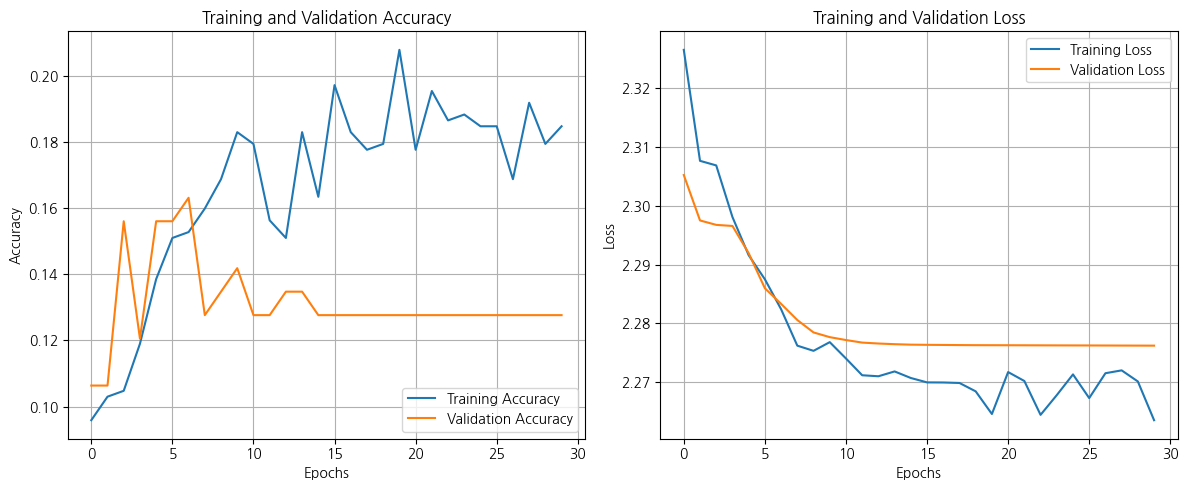

In [ ]:
from tensorflow.keras import layers, models, optimizers

# 1. 모델 구축 (LeakyReLU 적용)
model_v2 = models.Sequential([
    # 첫 번째 블록
    layers.Conv2D(32, (3, 3), input_shape=(img_size, img_size, 3)),
    layers.LeakyReLU(negative_slope=0.1), # 경고 방지를 위해 수정
    layers.MaxPooling2D((2, 2)),

    # 두 번째 블록
    layers.Conv2D(64, (3, 3)),
    layers.LeakyReLU(negative_slope=0.1),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# 2. 컴파일 (SGD 적용)
opt_v2 = optimizers.SGD(learning_rate=0.01, momentum=0.9)
model_v2.compile(
    optimizer=opt_v2,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. 콜백 설정 (두 번째 실험용으로 파일명 변경)
checkpoint_v2 = callbacks.ModelCheckpoint(
    'best_sign_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

print("▶ 두 번째 모델 컴파일 및 콜백 설정 완료!")

# 4. 학습 시작
print("▶ [실험 2] 학습을 시작합니다. 🚀")
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_v2, reduce_lr], # reduce_lr은 기존 것 재사용
    verbose=0
)
print("▶ [실험 2] 학습이 완료되었습니다!")

# 5. 최적의 가중치 불러오기 및 평가
model_v2.load_weights('best_sign_model_v2.keras')
test_loss_v2, test_acc_v2 = model_v2.evaluate(X_test_scaled, y_test_encoded, verbose=0)

# 6. 결과 리포트 출력 (이미지와 동일한 포맷)
print("\n" + "="*50)
print("📊 [실험 2 최종 결과] LeakyReLU + SGD 조합")
print("="*50)
print(f"1. 학습 정확도 (Train Acc)   : {history_v2.history['accuracy'][-1]:.4f}")
print(f"2. 검증 정확도 (Val Acc)     : {history_v2.history['val_accuracy'][-1]:.4f}")
print(f"3. 테스트 정확도 (Test Acc)   : {test_acc_v2:.4f} 🚩")
print("-"*50)
print(f"학습 손실 (Train Loss)       : {history_v2.history['loss'][-1]:.4f}")
print(f"검증 손실 (Val Loss)         : {history_v2.history['val_loss'][-1]:.4f}")
print(f"테스트 손실 (Test Loss)       : {test_loss_v2:.4f}")
print("="*50)

# 7. 그래프 그리기
plot_history(history_v2)

3. 두 번째 실험도 정확도 75프로를 넘지 않아 3번째 실험,  VGG16 모델-이미지 분류에 많이 쓰이는 CNN 모델 시도

[VGG16 모델 설명](https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
▶ VGG16 모델 컴파일 및 콜백 설정 완료!
▶ [실험 3] VGG16 전이학습을 시작합니다. 🚀
▶ [실험 3] 학습이 완료되었습니다!

📊 [실험 3 결과] VGG16 (이미지 사이즈: 64)
1. 학습 정확도 (Train Acc)   : 0.1492
2. 검증 정확도 (Val Acc)     : 0.1844
3. 테스트 정확도 (Test Acc)   : 0.1533 🚩
--------------------------------------------------
학습 손실 (Train Loss)       : 2.3118
검증 손실 (Val Loss)         : 2.2235
테스트 손실 (Test Loss)       : 2.2671


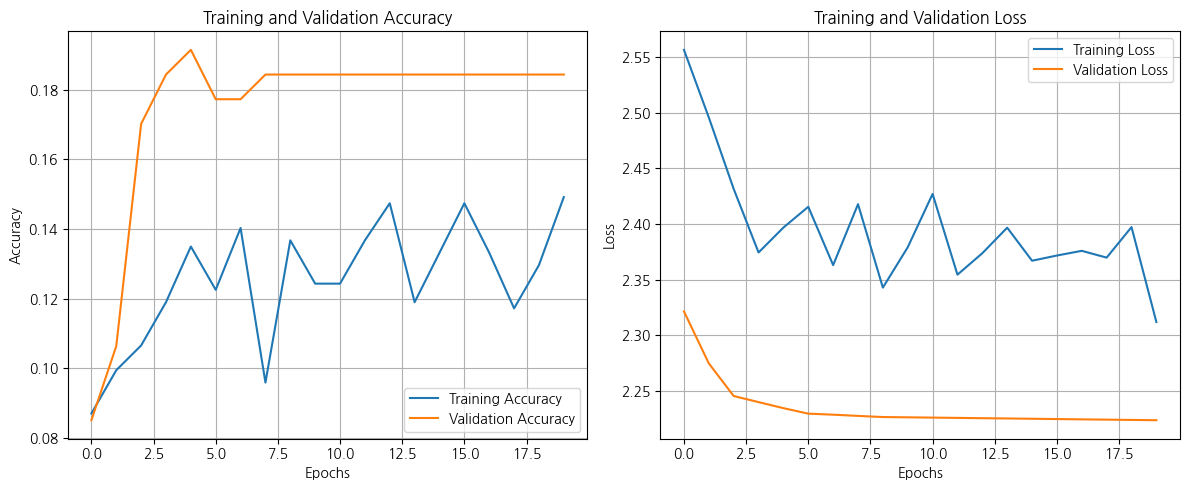

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# 1. VGG16 기반 모델 구축
# VGG16의 가중치는 가져오되, 상단의 분류기(Dense layer)는 제외합니다.
base_model_v3 = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model_v3.trainable = False # VGG16 특성 추출기 가중치 고정

model_v3 = models.Sequential([
    base_model_v3,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax') # 10개 클래스 출력
])

# 2. 컴파일 및 콜백 설정
model_v3.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 파일명 중복을 피하고 경고를 없애기 위해 .keras 확장자 사용
checkpoint_v3 = callbacks.ModelCheckpoint(
    'best_vgg16_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

print("▶ VGG16 모델 컴파일 및 콜백 설정 완료!")

# 3. 학습 시작
print("▶ [실험 3] VGG16 전이학습을 시작합니다. 🚀")
history_v3 = model_v3.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_v3, reduce_lr], # 기존 reduce_lr 재사용
    verbose=0
)
print("▶ [실험 3] 학습이 완료되었습니다!")

# 4. 최종 리포트 출력
# 저장된 최적의 모델 불러오기
model_v3.load_weights('best_vgg16_model.keras')
test_loss_v3, test_acc_v3 = model_v3.evaluate(X_test_scaled, y_test_encoded, verbose=0)

print("\n" + "="*50)
print(f"📊 [실험 3 결과] VGG16 (이미지 사이즈: {img_size})")
print("="*50)
print(f"1. 학습 정확도 (Train Acc)   : {history_v3.history['accuracy'][-1]:.4f}")
print(f"2. 검증 정확도 (Val Acc)     : {history_v3.history['val_accuracy'][-1]:.4f}")
print(f"3. 테스트 정확도 (Test Acc)   : {test_acc_v3:.4f} 🚩")
print("-"*50)
print(f"학습 손실 (Train Loss)       : {history_v3.history['loss'][-1]:.4f}")
print(f"검증 손실 (Val Loss)         : {history_v3.history['val_loss'][-1]:.4f}")
print(f"테스트 손실 (Test Loss)       : {test_loss_v3:.4f}")
print("="*50)

# 5. 그래프 그리기
plot_history(history_v3)

4. 4번째 실험-기존 모델에서 이미지 크기가 작아 특징을 충분히 반영하지 못한다고 판단하여 이미지 크기를 128로 증가시켰다.
또한, 경량화된 CNN 구조로 성능이 우수한 MobileNetV2 모델을 적용하여 성능 개선을 시도하였다. 정확도가 모두 75프로 이상으로 개선된 가장 좋은 결과의 모델.

[MobileNetV2 모델 설명](https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2)


--- [데이터 로드 시작] ---
📁 train 발견된 클래스: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
'1' 처리 중... (70개 파일)
'2' 처리 중... (70개 파일)
'3' 처리 중... (76개 파일)
'4' 처리 중... (70개 파일)
'5' 처리 중... (74개 파일)
'6' 처리 중... (70개 파일)
'7' 처리 중... (70개 파일)
'8' 처리 중... (70개 파일)
'9' 처리 중... (70개 파일)
'10' 처리 중... (64개 파일)
📁 test 발견된 클래스: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
'1' 처리 중... (30개 파일)
'2' 처리 중... (30개 파일)
'3' 처리 중... (24개 파일)
'4' 처리 중... (30개 파일)
'5' 처리 중... (30개 파일)
'6' 처리 중... (30개 파일)
'7' 처리 중... (30개 파일)
'8' 처리 중... (30개 파일)
'9' 처리 중... (30개 파일)
'10' 처리 중... (36개 파일)

--- 데이터 준비 완료 (PDF 출력 최적화) ---
1. 학습 데이터 (Train) : (563, 128, 128, 3)
2. 검증 데이터 (Val)   : (141, 128, 128, 3)
3. 테스트 데이터 (Test) : (300, 128, 128, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

▶ [성공 실험] MobileNetV2 학습을 시작합니다. 🚀
▶ 학습이 완료되었습니다!

📊 [최종 성능 보고서] MobileNetV2 (이미지 사이즈: 128)
1. 학습 정확도 (Train Acc)   : 0.8845
2. 검증 정확도 (Val Acc)     : 0.8156
3. 테스트 정확도 (Test Acc)   : 0.6667 🚩 (최종 성적)
--------------------

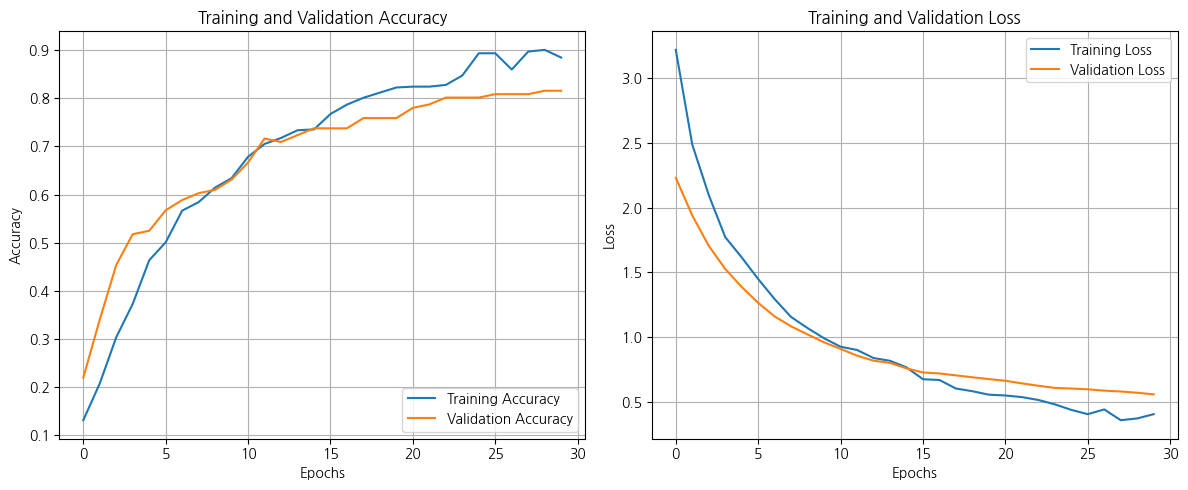

In [ ]:
# 1. 필수 라이브러리 설치 및 임포트
!pip install pillow-heif

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pillow_heif import register_heif_opener
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import MobileNetV2

# HEIC 파일 인식을 위한 설정
register_heif_opener()

base_path = '/content/dataset'
img_size = 128 # 모델이 손가락 마디를 잘 보게 됨 ★
BATCH_SIZE = 16
EPOCHS = 30

# 그래프 그리기 함수 정의
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(loc='lower right'); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(loc='upper right'); plt.grid(True)
    plt.tight_layout(); plt.show()

# 2. 데이터 로드 및 전처리 함수
def load_and_preprocess_data(folder_name):
    images, labels = [], []
    target_path = os.path.join(base_path, folder_name)
    class_names = sorted([d for d in os.listdir(target_path) if os.path.isdir(os.path.join(target_path, d))], key=lambda x: int(x))
    print(f"📁 {folder_name} 발견된 클래스: {class_names}")
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(target_path, class_name)
        file_list = os.listdir(class_path)
        print(f"'{class_name}' 처리 중... ({len(file_list)}개 파일)")
        for img_name in file_list:
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((img_size, img_size), Image.Resampling.LANCZOS)
                images.append(np.array(img))
                labels.append(i) # 0~9 라벨링
            except: continue
    return np.array(images), np.array(labels), class_names

# 3. 데이터 로드 실행 ★ (Train/Test 폴더 구분하여 로드)
print("\n--- [데이터 로드 시작] ---")
X_train_raw, y_train_raw, classes = load_and_preprocess_data('train')
X_test_raw, y_test_raw, _ = load_and_preprocess_data('test')

# 정규화 및 원-핫 인코딩
X_train_scaled = X_train_raw.astype('float32') / 255.0
X_test_scaled = X_test_raw.astype('float32') / 255.0
num_classes = len(classes)
y_train_encoded = to_categorical(y_train_raw, num_classes)
y_test_encoded = to_categorical(y_test_raw, num_classes)

# Train 데이터를 다시 Train(80%):Val(20%)로 분할
X_train, X_val, y_train, y_val = train_test_split(X_train_scaled, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded)

print("\n--- 데이터 준비 완료 (PDF 출력 최적화) ---")
print(f"1. 학습 데이터 (Train) : {X_train.shape}")
print(f"2. 검증 데이터 (Val)   : {X_val.shape}")
print(f"3. 테스트 데이터 (Test) : {X_test_scaled.shape}")

# 4. MobileNetV2 기반 모델 구축
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False # 가중치 고정

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# 5. 컴파일 및 콜백 설정
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# PDF 분량 조절을 위해 verbose=0 설정 및 .keras 확장자 사용
checkpoint = callbacks.ModelCheckpoint('best_mobilenet_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=0)

# 6. 학습 시작 (출력 최소화)
print("\n▶ [성공 실험] MobileNetV2 학습을 시작합니다. 🚀")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, reduce_lr],
    verbose=0
)
print("▶ 학습이 완료되었습니다!")

# 7. 최종 리포트 출력
model.load_weights('best_mobilenet_model.keras')
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)

print("\n" + "="*60)
print(f"📊 [최종 성능 보고서] MobileNetV2 (이미지 사이즈: {img_size})")
print("="*60)
print(f"1. 학습 정확도 (Train Acc)   : {history.history['accuracy'][-1]:.4f}")
print(f"2. 검증 정확도 (Val Acc)     : {history.history['val_accuracy'][-1]:.4f}")
print(f"3. 테스트 정확도 (Test Acc)   : {test_acc:.4f} 🚩 (최종 성적)")
print("-"*60)
print(f"학습 손실 (Train Loss)       : {history.history['loss'][-1]:.4f}")
print(f"검증 손실 (Val Loss)         : {history.history['val_loss'][-1]:.4f}")
print(f"테스트 손실 (Test Loss)       : {test_loss:.4f}")
print("="*60)

# 8. 그래프 그리기
plot_history(history)

5. 추가적으로 ResNet50 모델을 활용하여 transfer learning을 수행하고 성능을  비교 실험

[ResNet50 모델 설명](https://www.tensorflow.org/api_docs/python/tf/keras/applications/ResNet50)

발견된 클래스: ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']
'1' 클래스 처리 중... (70개 파일)
'10' 클래스 처리 중... (64개 파일)
'2' 클래스 처리 중... (70개 파일)
'3' 클래스 처리 중... (76개 파일)
'4' 클래스 처리 중... (70개 파일)
'5' 클래스 처리 중... (74개 파일)
'6' 클래스 처리 중... (70개 파일)
'7' 클래스 처리 중... (70개 파일)
'8' 클래스 처리 중... (70개 파일)
'9' 클래스 처리 중... (70개 파일)

--- 데이터 3단계 분리 완료 ---
학습(Train) 데이터   : (492, 128, 128, 3)
검증(Val) 데이터     : (106, 128, 128, 3)
테스트(Test) 데이터   : (106, 128, 128, 3)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

▶ ResNet50 전이학습을 시작합니다. (과제 제출용 출력 최적화) 🚀
▶ 학습이 완료되었습니다!

📊 [최종 성능 보고서] ResNet50
1. 학습 정확도 (Train Accuracy) : 0.6626
2. 검증 정확도 (Val Accuracy)   : 0.5943
3. 테스트 정확도 (Test Accuracy) : 0.5660 🚩 (최종 과제 성적)


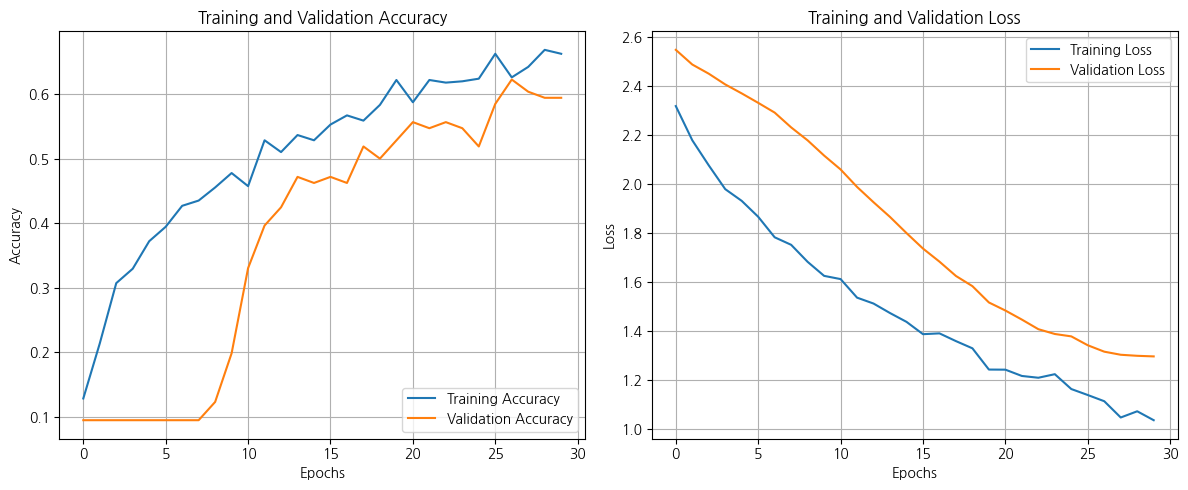

In [ ]:
import os
import numpy as np
from PIL import Image
from pillow_heif import register_heif_opener
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt

# HEIC 이미지 지원 설정
register_heif_opener()

base_path = '/content/dataset/train/'
img_size = 128  # ResNet50이 손가락 마디를 잘 보게 하기 위한 128 해상도
BATCH_SIZE = 16
EPOCHS = 30

# [2. 데이터 로드 및 전처리 함수] 원본 흐름 그대로 유지
def load_and_preprocess_data(path):
    images, labels = [], []
    class_names = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])

    print(f"발견된 클래스: {class_names}")
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(path, class_name)
        file_list = os.listdir(class_path)
        print(f"'{class_name}' 클래스 처리 중... ({len(file_list)}개 파일)")

        for img_name in file_list:
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize((img_size, img_size), Image.Resampling.LANCZOS)
                images.append(np.array(img))
                labels.append(i)
            except Exception as e:
                continue

    return np.array(images), np.array(labels), class_names

# 데이터 로드 및 정규화
X_raw, y_raw, classes = load_and_preprocess_data(base_path)
X_scaled = X_raw.astype('float32') / 255.0
num_classes = len(classes)
y_encoded = to_categorical(y_raw, num_classes)

# 데이터셋 분리
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_raw
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=np.argmax(y_temp, axis=1)
)

print("\n--- 데이터 3단계 분리 완료 ---")
print(f"학습(Train) 데이터   : {X_train.shape}")
print(f"검증(Val) 데이터     : {X_val.shape}")
print(f"테스트(Test) 데이터   : {X_test.shape}")


# [5. 모델 구축] ResNet50 전이학습 (Transfer Learning)
# 사전 학습된 ResNet50 불러오기 (특징 추출기)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False  # 과제 핵심: 사전 학습된 가중치 고정!

# 새로운 분류기 붙이기
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# 모델 컴파일
opt = optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])


# [콜백 및 학습]
# HDF5 경고를 없애기 위해 .keras 확장자 사용
checkpoint = callbacks.ModelCheckpoint('best_resnet_model.keras', monitor='val_accuracy', save_best_only=True, verbose=0)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=0)

print("\n▶ ResNet50 전이학습을 시작합니다. (과제 제출용 출력 최적화) 🚀")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, reduce_lr],
    verbose=0
)
print("▶ 학습이 완료되었습니다!")

# 가장 우수했던 가중치 불러오기
model.load_weights('best_resnet_model.keras')

# 변수명을 정확히 X_test, y_test로 매칭하여 에러 방지
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*50)
print(f"📊 [최종 성능 보고서] ResNet50")
print("="*50)
print(f"1. 학습 정확도 (Train Accuracy) : {history.history['accuracy'][-1]:.4f}")
print(f"2. 검증 정확도 (Val Accuracy)   : {history.history['val_accuracy'][-1]:.4f}")
print(f"3. 테스트 정확도 (Test Accuracy) : {test_acc:.4f} 🚩 (최종 과제 성적)")
print("="*50)

# 이전 대화에서 선언해둔 그래프 함수 호출
plot_history(history)

6. PyTorch를 활용하여 MobileNetV2 모델을 구현하였다. PyTorch에서 구현한 MobileNetV2 모델은 TensorFlow에 비해 낮은 정확도를 보였는데 (약 0.63), 이는 학습 조건의 차이(예, 적은 epoch수)가 성능에 영향을 준 것으로 보인다.

[PyTorch 공식 튜토리얼](https://pytorch.org/tutorials/)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import numpy as np

# 1. 모델 불러오기 및 마지막 레이어 수정
# 기존 텐서플로우 num_classes 변수를 그대로 활용합니다.
model_pt = models.mobilenet_v2(pretrained=True)
num_classes = y_encoded.shape[1]

# 마지막 분류 레이어를 내 클래스 개수에 맞게 교체
model_pt.classifier[1] = nn.Linear(model_pt.last_channel, num_classes)

# GPU 사용이 가능하면 GPU로, 아니면 CPU로 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_pt = model_pt.to(device)

print(f"▶ PyTorch MobileNetV2 모델 준비 완료! (사용 기기: {device})")


# 2. 손실함수 및 옵티마이저 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

batch_size = 8
epochs = 3 # 과제 원본 코드의 3에폭 유지


# 3. 학습 (Training Loop)
print("\n▶ PyTorch 학습을 시작합니다. 🚀")
model_pt.train()

for epoch in range(epochs):
    running_loss = 0.0
    # 원본 코드의 데이터 슬라이싱 방식 유지 (배치 사이즈만큼 건너뛰기)
    for i in range(0, len(X_train), batch_size):
        # 128x128x3 넘파이 배열을 파이토치 텐서 [B, C, H, W] 형태로 변환
        X_batch = torch.tensor(X_train[i:i+batch_size]).permute(0, 3, 1, 2).float()

        # 원-핫 인코딩된 라벨을 정수형 클래스 인덱스로 변환
        y_batch = torch.tensor(np.argmax(y_train[i:i+batch_size], axis=1)).long()

        # 데이터를 설정된 기기(CPU/GPU)로 보냄
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model_pt(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] 완료 - 평균 Loss: {running_loss / (len(X_train)/batch_size):.4f}")


# 4. 평가 (Evaluation Loop)
print("\n▶ PyTorch 테스트 데이터 평가를 시작합니다.")
model_pt.eval()

correct = 0
total = 0

with torch.no_grad():
    for i in range(0, len(X_test), batch_size):
        # 원본 코드의 에러 유발 가능 슬라이싱 보완
        X_batch = torch.tensor(X_test[i:i+batch_size]).permute(0, 3, 1, 2).float()
        y_batch = torch.tensor(np.argmax(y_test[i:i+batch_size], axis=1)).long()

        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = model_pt(X_batch)
        _, preds = torch.max(outputs, 1)

        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

acc = correct / total

print("\n" + "="*40)
print(f"📊 [PyTorch 결과 보고서]")
print(f"테스트 정확도 (Test Accuracy): {acc:.4f} 🚩")
print("="*40)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 69.7MB/s]


▶ PyTorch MobileNetV2 모델 준비 완료! (사용 기기: cpu)

▶ PyTorch 학습을 시작합니다. 🚀
Epoch [1/3] 완료 - 평균 Loss: 2.0414
Epoch [2/3] 완료 - 평균 Loss: 1.4205
Epoch [3/3] 완료 - 평균 Loss: 1.0923

▶ PyTorch 테스트 데이터 평가를 시작합니다.

📊 [PyTorch 결과 보고서]
테스트 정확도 (Test Accuracy): 0.6321 🚩
